# Homework 6

*Photometry* <br>
*Riddhi Patel* <br>
*April 2026*





---
I usually have a table of contents section but I ran out of time unlike other homeworks :( Sorry that my prose isn't nearly as thorough as it normally is!!!
---

## Setup <a class="anchor" id="setup"></a>

This section serves as a setup for CCD Reduction calculations done later! 

We have the import block, and some helper functions that are used later for quicker image plotting. 

### Import Block <a class="anchor" id="import"></a>

In [1369]:
# IMPORT BLOCK

# import block
# some of these may not be needed
import numpy as np
from astropy.io import fits
import pdb
%matplotlib inline
from matplotlib import pyplot as plt
from matplotlib import rc
import matplotlib
from astropy.visualization import hist, simple_norm, ZScaleInterval
from datetime import datetime
from pathlib import Path
import os
from ccdproc import ImageFileCollection
import ccdproc as ccdp
from astropy.modeling.models import Polynomial1D,Chebyshev1D,Legendre1D,Hermite1D, Gaussian1D,Gaussian2D,Polynomial2D
from astropy.modeling import fitting
from astropy.stats import mad_std
from astropy.nddata import CCDData, StdDevUncertainty
from scipy import stats
from astropy import units as u
from photutils.aperture import CircularAperture,CircularAnnulus
from photutils.aperture import aperture_photometry
from photutils.utils import calc_total_error
from astropy.stats import sigma_clipped_stats
from photutils.detection import DAOStarFinder
from astropy.table import Table
from photutils.datasets import make_100gaussians_image
import glob
from scipy.spatial import cKDTree

from astropy.coordinates import SkyCoord

def imshow_file(file, title):
    img = fits.getdata(file)

    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(img)
    plt.imshow(img, vmin=vmin, vmax=vmax)
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.title(title)
    plt.show()

def imshow_array(array, title):
    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(array)
    plt.imshow(array, vmin=vmin, vmax=vmax)
    plt.grid(False)
    # plt.xticks([])
    # plt.yticks([])
    plt.title(title)
    plt.show()

In [ ]:

## DEFINE DATA DIRECTORY AND BIAS/DARKS/FLATS/SCIENCE FILES LISTS

data_dir = '/Users/pater32/Documents/GitHub/astr_8060_s26/work/ripatel/image_combination/Imaging/' ## I have separate locations for linearity test files so this can be changed to wherever yours are!
reduced_dir = '/Users/pater32/Documents/GitHub/astr_8060_s26/work/ripatel/hw_submission/HW4/reduced_files/'

linearity_test_files = sorted(
    glob.glob(data_dir+'a07[4-9].fits') + #74-79
    glob.glob(data_dir+'a080.fits')       #80
)

linearity_test_array = np.array([fits.getdata(file) for file in linearity_test_files])
linearity_test_trimsec = np.array([file[:, 53:2101] for file in linearity_test_array])
linearity_test_exptimes = np.array([fits.getheader(file)['EXPTIME'] for file in linearity_test_files])

pg_files = sorted(
    glob.glob(reduced_dir+'a06[4-9]_otzf.fits') + #64-69
    glob.glob(reduced_dir+'a07[0-9]_otzf.fits') + #70-79
    glob.glob(reduced_dir+'a08[0-9]_otzf.fits') + #80-89
    glob.glob(reduced_dir+'a09[0-2]_otzf.fits') + #90-92
    glob.glob(reduced_dir+'a13[0-9]_otzf.fits') + #130-139
    glob.glob(reduced_dir+'a20[2-9]_otzf.fits') + #202-209
    glob.glob(reduced_dir+'a21[0-1]_otzf.fits') + #210-211
    glob.glob(reduced_dir+'a22[1-9]_otzf.fits') + #221-229 (We don't have any of these)
    glob.glob(reduced_dir+'a23[0-9]_otzf.fits') + #230-239 (We only have #237-239)
    glob.glob(reduced_dir+'a24[0-6]_otzf.fits')   #240-246
)

pg_files_u = sorted(
    glob.glob(reduced_dir+'a08[1-2]_otzf.fits') + #81-82
    glob.glob(reduced_dir+'a13[0-1]_otzf.fits') + #130-131
    glob.glob(reduced_dir+'a20[2-3]_otzf.fits') + #202-203
    glob.glob(reduced_dir+'a22[1-2]_otzf.fits') + #221-222
    glob.glob(reduced_dir+'a23[7-8]_otzf.fits')   #237-238
)
print(len(pg_files_u))

pg_files_b = sorted(
    glob.glob(reduced_dir+'a08[3-4]_otzf.fits') + #83-84
    glob.glob(reduced_dir+'a13[2-3]_otzf.fits') + #132-133
    glob.glob(reduced_dir+'a20[4-5]_otzf.fits') + #204-205
    glob.glob(reduced_dir+'a22[3-6]_otzf.fits') + #223-226
    glob.glob(reduced_dir+'a239_otzf.fits')     + #239
    glob.glob(reduced_dir+'a240_otzf.fits')       #240
)
print(len(pg_files_b))

pg_files_v = sorted(
    glob.glob(reduced_dir+'a08[5-6]_otzf.fits') + #85-86
    glob.glob(reduced_dir+'a13[4-5]_otzf.fits') + #134-135
    glob.glob(reduced_dir+'a20[6-7]_otzf.fits') + #206-207
    glob.glob(reduced_dir+'a22[7-9]_otzf.fits') + #227-229
    glob.glob(reduced_dir+'a230_otzf.fits')     + #230
    glob.glob(reduced_dir+'a24[1-2]_otzf.fits')   #241-242
)
print(len(pg_files_v))

pg_files_r = sorted(
    glob.glob(reduced_dir+'a08[7-8]_otzf.fits') + #87-88
    glob.glob(reduced_dir+'a13[6-7]_otzf.fits') + #136-137
    glob.glob(reduced_dir+'a20[8-9]_otzf.fits') + #208-209
    glob.glob(reduced_dir+'a22[7-9]_otzf.fits') + #227-229
    glob.glob(reduced_dir+'a23[1-2]_otzf.fits') + #231-232
    glob.glob(reduced_dir+'a23[5-6]_otzf.fits') + #235-236
    glob.glob(reduced_dir+'a24[3-4]_otzf.fits')   #243-244
)
print(len(pg_files_r))

pg_files_i = sorted(
    glob.glob(reduced_dir+'a089_otzf.fits')     + #89
    glob.glob(reduced_dir+'a090_otzf.fits')     + #90
    glob.glob(reduced_dir+'a13[8-9]_otzf.fits') + #138-139
    glob.glob(reduced_dir+'a21[0-1]_otzf.fits') + #210-211
    glob.glob(reduced_dir+'a23[3-4]_otzf.fits') + #233-234
    glob.glob(reduced_dir+'a24[5-6]_otzf.fits')   #245-246
)
print(len(pg_files_i))



8
8
8
8
8


This section globbed all the necessary files that'll be needed for subsequent analysis! In particular, the PG1633 files by various filter is separated out so we can do photometry by band. 

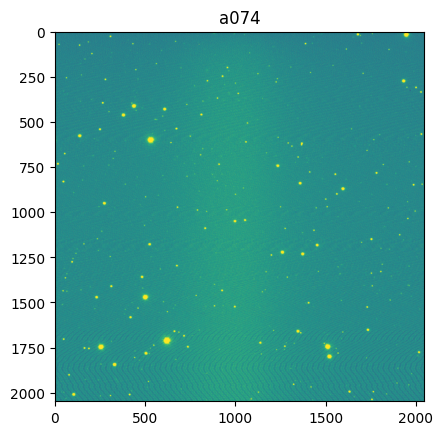

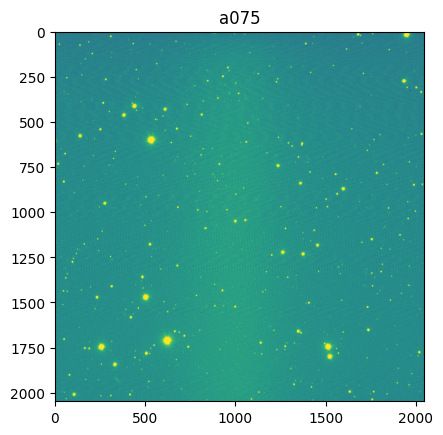

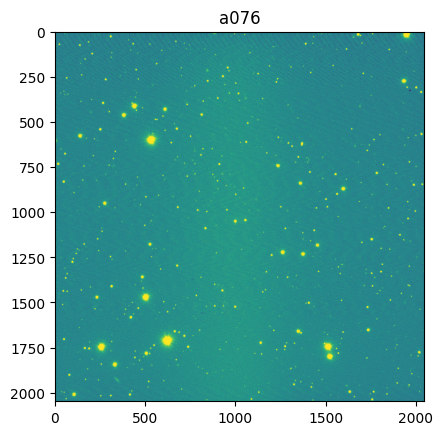

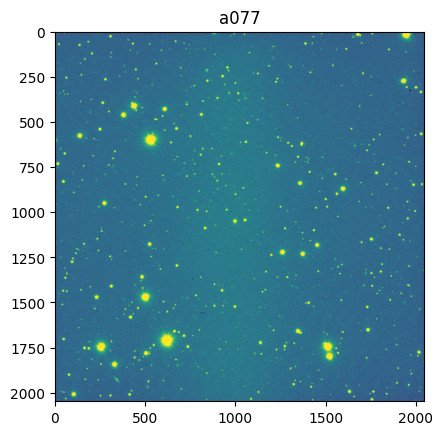

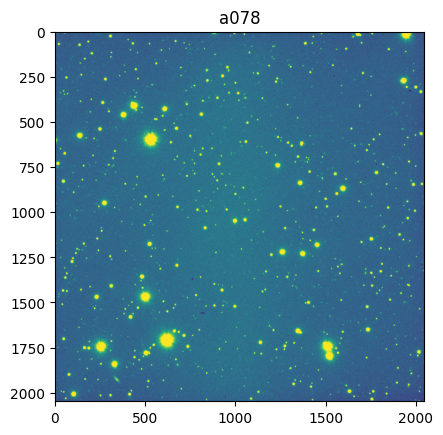

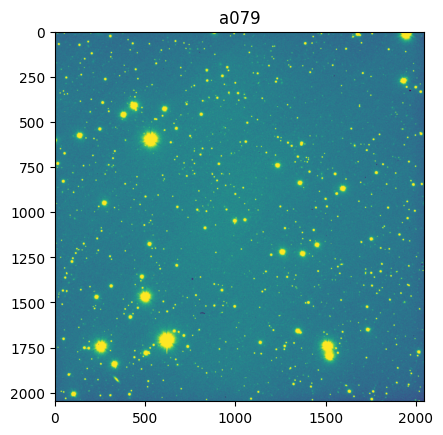

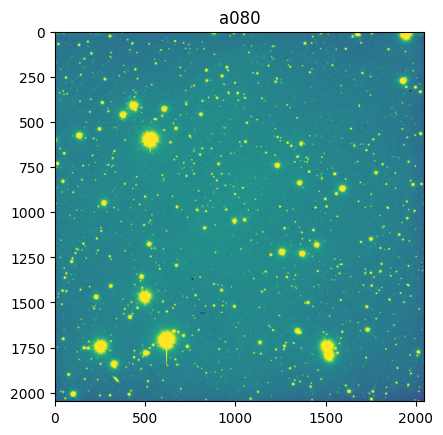

[4.10180883 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883
 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883
 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883
 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883
 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883
 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883
 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883
 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883
 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883
 4.10180883 4.10180883 4.10180883 4.10180883 4.10180883]


In [1371]:
## VISUAL CHECKS ON THE LINEAR TEST FILES

i = 74
for array in linearity_test_trimsec:
    imshow_array(array, "a0"+str(i))
    i += 1


print(np.array([fits.getheader(file)['AIRMASS'] for file in pg_files]))

    

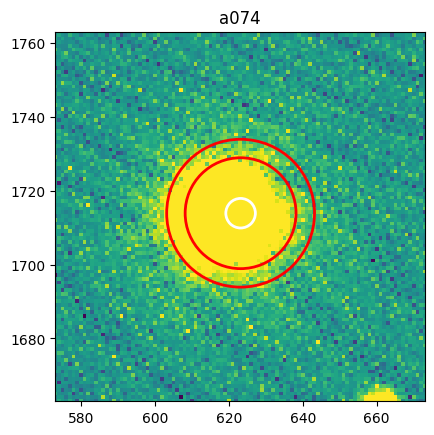

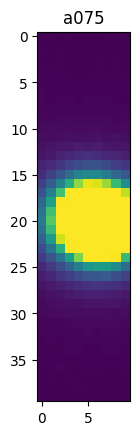

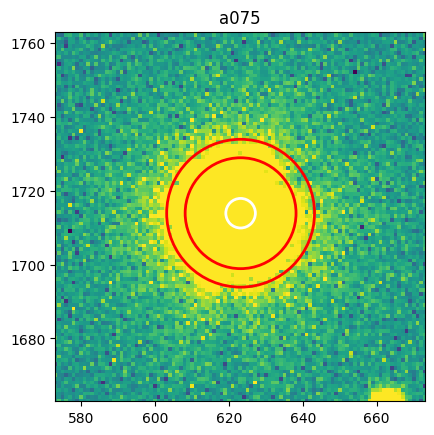

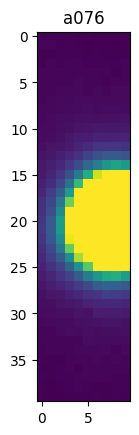

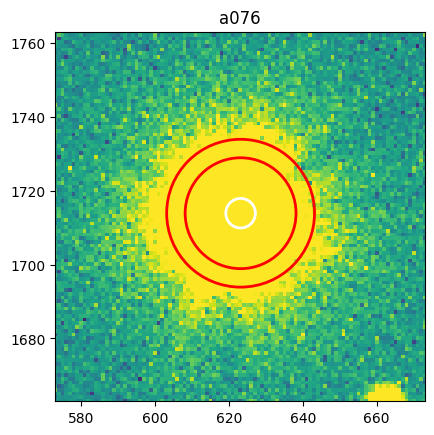

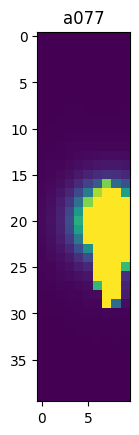

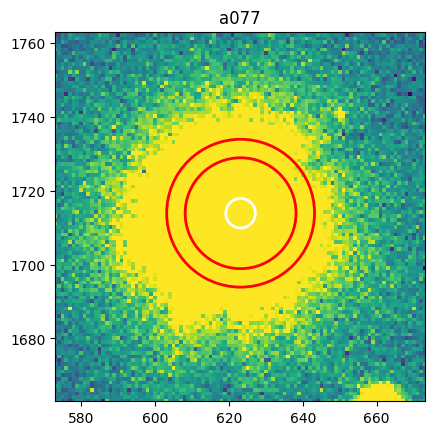

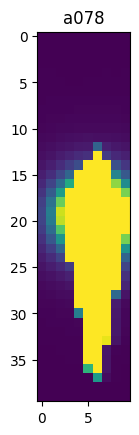

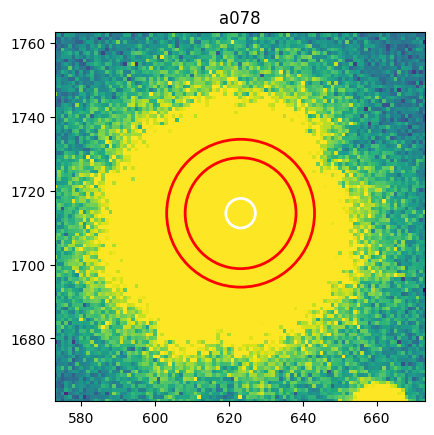

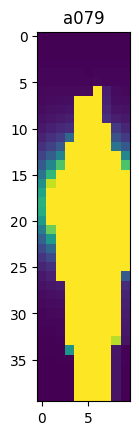

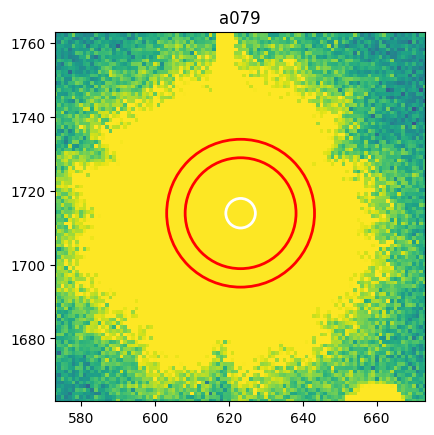

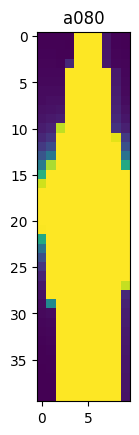

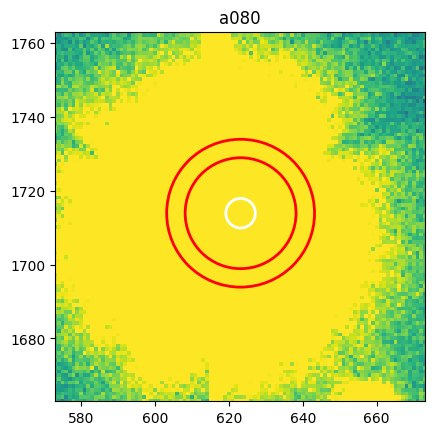

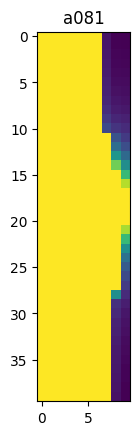

In [1372]:
def show_apertures(image, positions, title, aperture_radius, annulus_radius_in, annulus_radius_out, xlim_lower, xlim_upper, ylim_lower, ylim_upper):
    data = make_100gaussians_image()
    aperture = CircularAperture(positions, r=aperture_radius)
    annulus_aperture = CircularAnnulus(positions, r_in=annulus_radius_in, r_out=annulus_radius_out)

    interval = ZScaleInterval()
    vmin, vmax = interval.get_limits(image)


    plt.imshow(image, vmin=vmin, vmax=vmax)
    aperture.plot(color='white', lw=2,label='Photometry aperture')
    annulus_aperture.plot(color='red', lw=2, label='Background annulus')
    plt.title(title)
    plt.xlim(xlim_lower, xlim_upper)
    plt.ylim(ylim_lower, ylim_upper)
    plt.grid(False)
    # plt.xticks([])
    # plt.yticks([])
    plt.show()

x1 = 623.18986
x = int(x1)
y1 = 1713.8842
y = int(y1)
star_position = [(x1,y1)]

delta_y = 20
delta_x = 10

i = 74
for array in linearity_test_trimsec:
    show_apertures(array, star_position, 'a0'+str(i), 4, 15, 20, x-50, x+50, y-50, y+50)
    i += 1

    imshow_array(array[y-delta_y:y+delta_y, x-delta_x:x], 'a0'+str(i))

    

This section shows me what cross-sections I'm actually using to get values for my linearity test. I played around a lot with them to get a somewhat straight line, so this was really helpful for me to visualize which pixels were getting saturated and when!

3128.59
4726.785
7143.225
15346.035
30466.31
43736.45
54218.475


Text(0.5, 0, 'Exposure Time (s)')

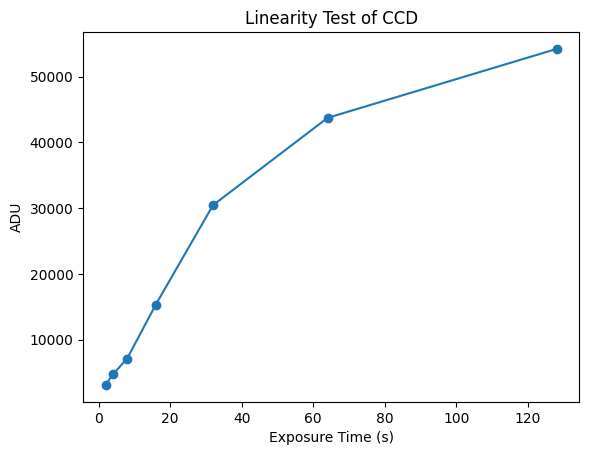

In [1373]:
total_avg = []
for array in linearity_test_trimsec:
    data = array[y-delta_y:y, x-delta_x:x]
    average = np.mean(data)
    total_avg.append(average)
    print(average)


plt.plot(linearity_test_exptimes, total_avg, marker='o')
plt.title('Linearity Test of CCD')
plt.ylabel('ADU')
plt.xlabel('Exposure Time (s)')


Here, we can see the signal increases with exposure time...yay! With higher exposure times, we see higher ADU levels. 

To get an ADU value, I used the average pixel value of a small section including a very bright star. I did this because the max shows that the CCD almost fully saturates within 3 seconds, so that isn't super helpful. It's not entirely linear, but I did look at the average of the entire image and that looks fairly linear, but doesn't come close to saturation levels...naturally because the entire image shouldn't be saturated (that would be very scary). I got it close enough to linear that I felt okay to move on! If I had more time, I would've played around with different sections a bit more!

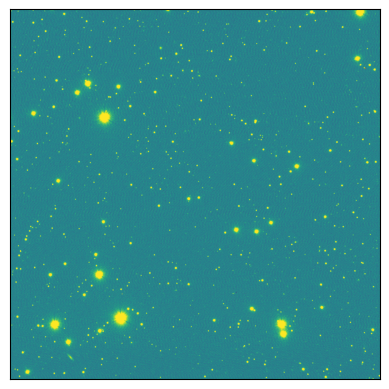

In [ ]:
## SELECT ONE OTZF FILE TO USE 

img, header = fits.getdata(reduced_dir + 'a085_otzf.fits', header=True)

interval = ZScaleInterval()
vmin, vmax = interval.get_limits(img)


plt.imshow(img, vmin=vmin, vmax=vmax) 
plt.grid(False)
plt.xticks([])
plt.yticks([])
plt.show()

In [ ]:
## PICK THREE STARS THAT HAVE VARIOUS BRIGHTNESS LEVELS

x1 = 475.22622
x2 = 267.59238
x3 = 1697.6051
y1 = 1358.926
y2 = 951.01654
y3 = 231.53351
positions = [(x1,y1),(x2,y2),(x3,y3)]

I found these positions using DS9 and hovering over the center of the stars to see how much the CCD was saturated. I picked a low value for faint stars, medium for medium-faint, and high for bright! The size of the star definitely helped as well to determine which ones are brighter. 

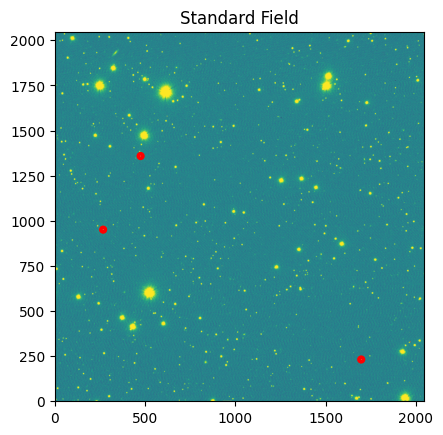

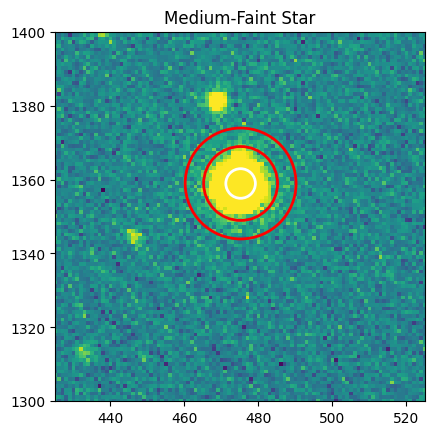

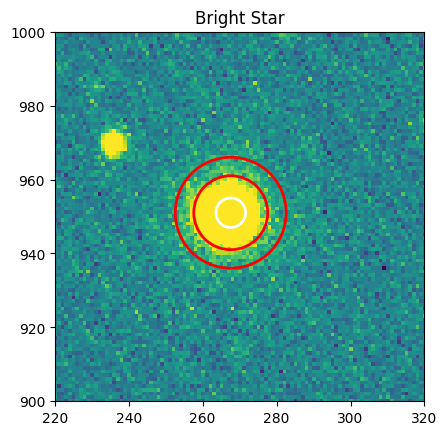

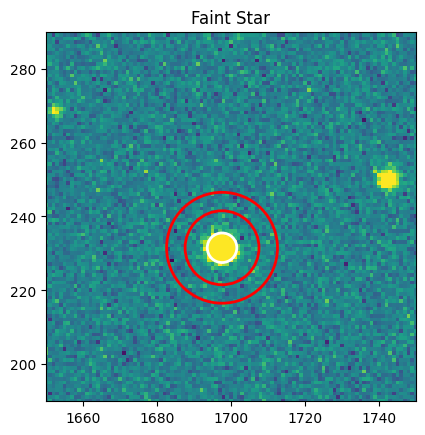

In [1376]:
## SHOW APERTURES FOR EACH STAR CHOICE

show_apertures(img, positions, 'Standard Field', 4.0, 10, 15, 0, 2048, 0, 2048)
show_apertures(img, positions, 'Medium-Faint Star', 4.0, 10, 15, 425, 525, 1300, 1400)
show_apertures(img, positions, 'Bright Star', 4.0, 10, 15, 220, 320, 900, 1000)
show_apertures(img, positions, 'Faint Star', 4.0, 10, 15, 1650, 1750, 190, 290)


I plotted the apertures and annuli for the stars I chose to make sure they're reasonable choices! They look reasonable to me :^)

Let's see if they're really good choices in the next steps...

62449.003363053685


Text(0, 0.5, 'SNR')

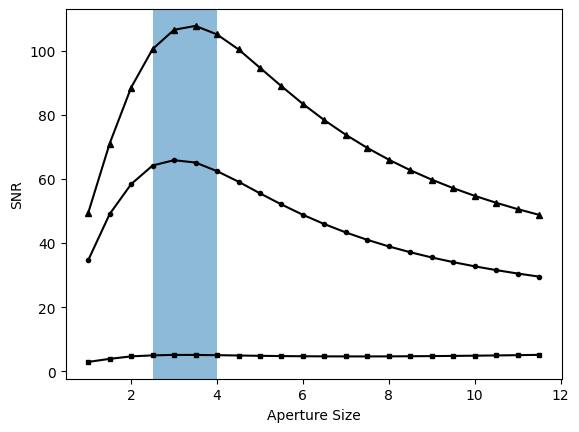

In [1377]:
## PERFORM APERTURE PHOTOMETRY

aperture_radius = 4
error = 0.7*np.ones((2048,2048))
apertures = CircularAperture(positions, r=aperture_radius)
phot_table = aperture_photometry(img, apertures,  error=error)
phot_table['id'] = ["Medium-Faint", "Bright", "Faint"]
phot_table['aperture_areas'] = apertures.area
phot_table['snr'] = phot_table['aperture_sum']/phot_table['aperture_sum_err']


print(phot_table['snr'][0])

aperture_range = np.arange(1, 12, 0.5)
snr_faint = []
snr_medfaint = []
snr_bright = []
for aperture in aperture_range:
    apertures = CircularAperture(positions, r=aperture)
    phot_table = aperture_photometry(img, apertures,  error=error)
    phot_table['id'] = ["Medium-Faint", "Bright", "Faint"]
    phot_table['aperture_areas'] = apertures.area
    phot_table['snr'] = phot_table['aperture_sum']/phot_table['aperture_sum_err']
    snr_medfaint.append(phot_table['snr'][0])
    snr_faint.append(phot_table['snr'][2])
    snr_bright.append(phot_table['snr'][1])

plt.plot(aperture_range,
            np.array(snr_medfaint)/1000,
            color = 'black',
            marker = 'o',
            markersize = 3
            )
plt.plot(aperture_range,
            np.array(snr_bright)/1000,
            color = 'black',
            marker = '^',
            markersize = 5
            )
plt.plot(aperture_range,
            np.array(snr_faint)/1000,
            color = 'black',
            marker = 's',
            markersize = 3
            )
plt.axvspan(2.5, 4, alpha=0.5)
plt.xlabel('Aperture Size')
plt.ylabel('SNR')

YIPPEE!! They are reasonable! 

I initially chose an aperture radius ~ the same size as my faint star. I also assumed an error of .7 across all of my pixels, which I know is unrealistic but I made a very simplifying assumption to see if my plot would end up like the one in Howell. This is also an error that's used in one of the examples in the photutils documentation. Fortunately, it looks very close to Howell! 

My faint star's line does have a similar shape to the medium-faint and bright stars as well when I zoomed into it. It's just very faint so it looks completely flattened. 

From this, we can see that the peak signal is shown at aperture sizes between 2.5-4. For subsequent analyses, I went with a aperture radius of 3 pixels!

In [ ]:
## EXTRACT INSTRUMENTAL MAGNITUDES

## positions for a082_otzf file
# x1 = 991.31832
# y1 = 1050.2277
# x2 = 1047.8091
# y2 = 1043.7664
# x3 = 1254.1037
# y3 = 1221.5112
# x4 = 1366.9188
# y4 = 1231.4593
# x5 = 1446.544
# y5 = 1182.4049
# positions = [(x1, y1), (x2, y2), (x3, y3), (x4, y4), (x5, y5)]

true_mag = [14.397, 15.256, 12.969, 13.229, 13.691]


position_offsets_u = [(-1, -1), (0, 0), (-58, -7), (-59, -7), (-67, -13), (-67, -13), (-155, -12), (-155, -12)]
u_files = len(pg_files_u)
del_m_u = []
mag_u = []
i = 0
for file in pg_files_u:
    if i <= u_files:
        img = fits.getdata(file)
        x_offset = position_offsets_u[i][0]
        y_offset = position_offsets_u[i][1]

        x1 = 991.31832
        y1 = 1050.2277
        x2 = 1047.8091
        y2 = 1043.7664
        x3 = 1254.1037
        y3 = 1221.5112
        x4 = 1366.9188
        y4 = 1231.4593
        x5 = 1446.544
        y5 = 1182.4049
        positions = [(x1+x_offset, y1+y_offset), 
                     (x2+x_offset, y2+y_offset), 
                     (x3+x_offset, y3+y_offset), 
                     (x4+x_offset, y4+y_offset), 
                     (x5+x_offset, y5+y_offset)]


        # show_apertures(img, positions, file[-14:-5], 3.0, 10, 15, 900, 1500, 1000, 1300)
        i += 1
    aperture_radius = 3
    apertures = CircularAperture(positions, r=aperture_radius)
    annulus_aperture = CircularAnnulus(positions, r_in=10, r_out=15)

    phot_table = aperture_photometry(img, apertures)
    phot_annulus = aperture_photometry(img, annulus_aperture)

    bkg = phot_annulus['aperture_sum']/ annulus_aperture.area
    bkg_total = bkg * apertures.area

    exp_time = fits.getheader(file)['EXPTIME']
    mag = -2.5 * np.log10((phot_table['aperture_sum'] - bkg_total)/exp_time)
    phot_table['mag'] = mag
    phot_table['del_m'] = phot_table['mag'] - np.array(true_mag)

    mag_u.append(list(phot_table['mag']))
    del_m_u.append(list(phot_table['del_m']))




position_offsets_b = [(-1, -1), (-3, -1), (-59, -7), (-60, -7), (-67, -13), (-67, -13), (-154, -11), (-154, -11)]
b_files = len(pg_files_b)
del_m_b = []
mag_b = []
i = 0
for file in pg_files_b:
    if i <= b_files:
        img = fits.getdata(file)
        x_offset = position_offsets_b[i][0]
        y_offset = position_offsets_b[i][1]

        x1 = 991.31832
        y1 = 1050.2277
        x2 = 1047.8091
        y2 = 1043.7664
        x3 = 1254.1037
        y3 = 1221.5112
        x4 = 1366.9188
        y4 = 1231.4593
        x5 = 1446.544
        y5 = 1182.4049
        positions = [(x1+x_offset, y1+y_offset), 
                     (x2+x_offset, y2+y_offset), 
                     (x3+x_offset, y3+y_offset), 
                     (x4+x_offset, y4+y_offset), 
                     (x5+x_offset, y5+y_offset)]


        # show_apertures(img, positions, file[-14:-5], 3.0, 10, 15, 900, 1500, 1000, 1300)
        i += 1
    aperture_radius = 3
    apertures = CircularAperture(positions, r=aperture_radius)
    annulus_aperture = CircularAnnulus(positions, r_in=10, r_out=15)

    phot_table = aperture_photometry(img, apertures)
    phot_annulus = aperture_photometry(img, annulus_aperture)

    bkg = phot_annulus['aperture_sum']/ annulus_aperture.area
    bkg_total = bkg * apertures.area

    exp_time = fits.getheader(file)['EXPTIME']
    mag = -2.5 * np.log10((phot_table['aperture_sum'] - bkg_total)/exp_time)
    phot_table['mag'] = mag
    phot_table['del_m'] = phot_table['mag'] - np.array(true_mag)
    mag_b.append(list(phot_table['mag']))
    del_m_b.append(list(phot_table['del_m']))

position_offsets_v = [(-3, -1), (-4, -1), (-60, -7), (-60, -7), (-67, -13), (-67, -13), (-154, -10), (-154, -11)]
v_files = len(pg_files_v)
del_m_v = []
mag_v = []
i = 0
for file in pg_files_v:
    if i <= v_files:
        img = fits.getdata(file)
        x_offset = position_offsets_v[i][0]
        y_offset = position_offsets_v[i][1]

        x1 = 991.31832
        y1 = 1050.2277
        x2 = 1047.8091
        y2 = 1043.7664
        x3 = 1254.1037
        y3 = 1221.5112
        x4 = 1366.9188
        y4 = 1231.4593
        x5 = 1446.544
        y5 = 1182.4049
        positions = [(x1+x_offset, y1+y_offset), 
                     (x2+x_offset, y2+y_offset), 
                     (x3+x_offset, y3+y_offset), 
                     (x4+x_offset, y4+y_offset), 
                     (x5+x_offset, y5+y_offset)]


        # show_apertures(img, positions, file[-14:-5], 3.0, 10, 15, 900, 1500, 1000, 1300)
        i += 1
    aperture_radius = 3
    apertures = CircularAperture(positions, r=aperture_radius)
    annulus_aperture = CircularAnnulus(positions, r_in=10, r_out=15)

    phot_table = aperture_photometry(img, apertures)
    phot_annulus = aperture_photometry(img, annulus_aperture)

    bkg = phot_annulus['aperture_sum']/ annulus_aperture.area
    bkg_total = bkg * apertures.area

    exp_time = fits.getheader(file)['EXPTIME']
    mag = -2.5 * np.log10((phot_table['aperture_sum'] - bkg_total)/exp_time)
    phot_table['mag'] = mag
    phot_table['del_m'] = phot_table['mag'] - np.array(true_mag)

    mag_v.append(list(phot_table['mag']))
    del_m_v.append(list(phot_table['del_m']))

position_offsets_r = [(-3, 0), (-5, -1), (-60, -6), (-60, -6), (-67, -13), (-67, -12), (-154, -9), (-152, -9)]
r_files = len(pg_files_r)
del_m_r = []
mag_r = []
i = 0
for file in pg_files_r:
    if i <= r_files:
        img = fits.getdata(file)
        x_offset = position_offsets_r[i][0]
        y_offset = position_offsets_r[i][1]

        x1 = 991.31832
        y1 = 1050.2277
        x2 = 1047.8091
        y2 = 1043.7664
        x3 = 1254.1037
        y3 = 1221.5112
        x4 = 1366.9188
        y4 = 1231.4593
        x5 = 1446.544
        y5 = 1182.4049
        positions = [(x1+x_offset, y1+y_offset), 
                     (x2+x_offset, y2+y_offset), 
                     (x3+x_offset, y3+y_offset), 
                     (x4+x_offset, y4+y_offset), 
                     (x5+x_offset, y5+y_offset)]


        # show_apertures(img, positions, file[-14:-5], 3.0, 10, 15, 900, 1500, 1000, 1300)
        i += 1
    aperture_radius = 3
    apertures = CircularAperture(positions, r=aperture_radius)
    annulus_aperture = CircularAnnulus(positions, r_in=10, r_out=15)

    phot_table = aperture_photometry(img, apertures)
    phot_annulus = aperture_photometry(img, annulus_aperture)

    bkg = phot_annulus['aperture_sum']/ annulus_aperture.area
    bkg_total = bkg * apertures.area

    exp_time = fits.getheader(file)['EXPTIME']
    mag = -2.5 * np.log10((phot_table['aperture_sum'] - bkg_total)/exp_time)
    phot_table['mag'] = mag
    phot_table['del_m'] = phot_table['mag'] - np.array(true_mag)

    mag_r.append(list(phot_table['mag']))
    del_m_r.append(list(phot_table['del_m']))

position_offsets_i = [(-6, 0), (-8, 0), (-61, -5), (-61, -5), (-68, -11), (-68, -11), (-154, -9), (-153, -9)]
i_files = len(pg_files_i)
del_m_i = []
mag_i = []
i = 0
for file in pg_files_i:
    if i <= i_files:
        img = fits.getdata(file)
        x_offset = position_offsets_i[i][0]
        y_offset = position_offsets_i[i][1]

        x1 = 991.31832
        y1 = 1050.2277
        x2 = 1047.8091
        y2 = 1043.7664
        x3 = 1254.1037
        y3 = 1221.5112
        x4 = 1366.9188
        y4 = 1231.4593
        x5 = 1446.544
        y5 = 1182.4049
        positions = [(x1+x_offset, y1+y_offset), 
                     (x2+x_offset, y2+y_offset), 
                     (x3+x_offset, y3+y_offset), 
                     (x4+x_offset, y4+y_offset), 
                     (x5+x_offset, y5+y_offset)]


        # show_apertures(img, positions, file[-14:-5], 3.0, 10, 15, 900, 1500, 1000, 1300)
        i += 1
    aperture_radius = 3
    apertures = CircularAperture(positions, r=aperture_radius)
    annulus_aperture = CircularAnnulus(positions, r_in=10, r_out=15)

    phot_table = aperture_photometry(img, apertures)
    phot_annulus = aperture_photometry(img, annulus_aperture)

    bkg = phot_annulus['aperture_sum']/ annulus_aperture.area
    bkg_total = bkg * apertures.area

    exp_time = fits.getheader(file)['EXPTIME']
    mag = -2.5 * np.log10((phot_table['aperture_sum'] - bkg_total)/exp_time)
    phot_table['mag'] = mag
    phot_table['del_m'] = phot_table['mag'] - np.array(true_mag)

    mag_i.append(list(phot_table['mag']))
    del_m_i.append(list(phot_table['del_m']))


This entire step is about trying to extract instrumental magnitudes. Each of our stars shifts, so we need to account for that when we think about our centroids. The method I ended up going with is picking out 1 standard star and manually applying shifts to it for each band. Then I tweaked it until it looked pretty centered. Then, I applied that same offset to all of the other stars in the same file and band!

From there, I calculated instrumental magnitude using aperture_photometry and normalizing for exposure time. 

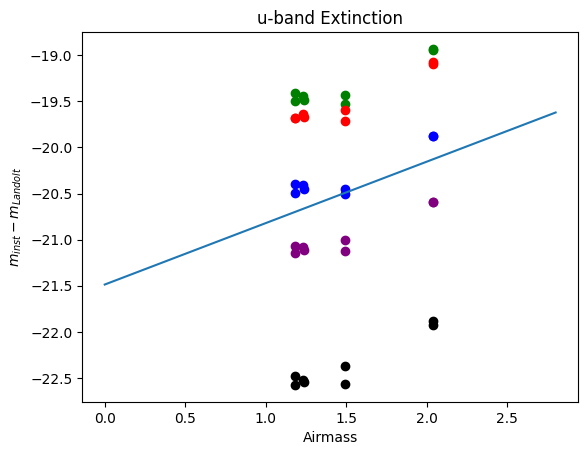

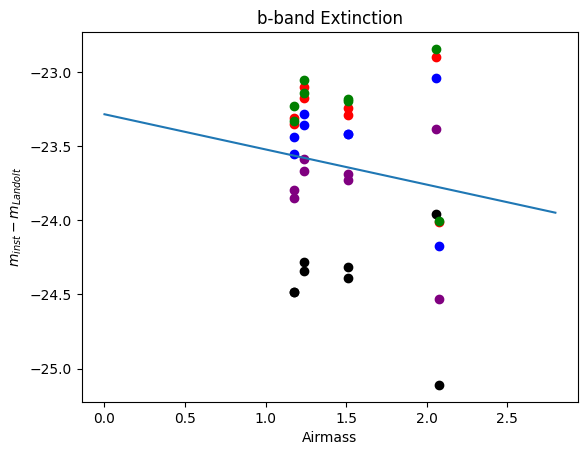

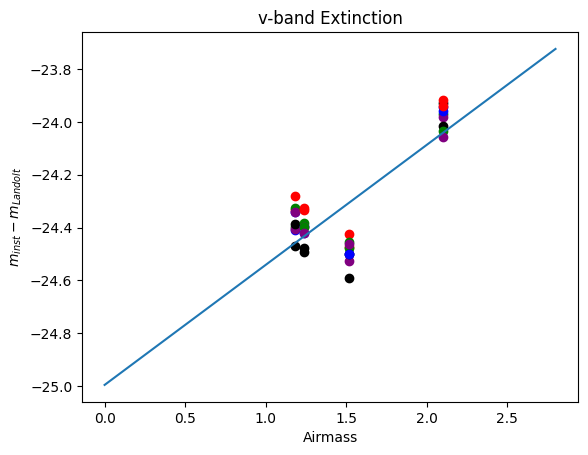

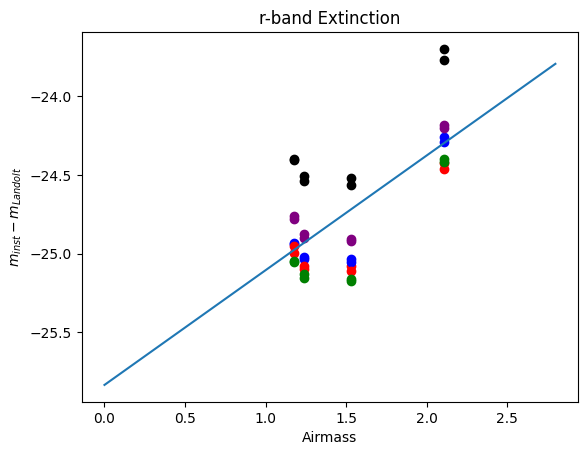

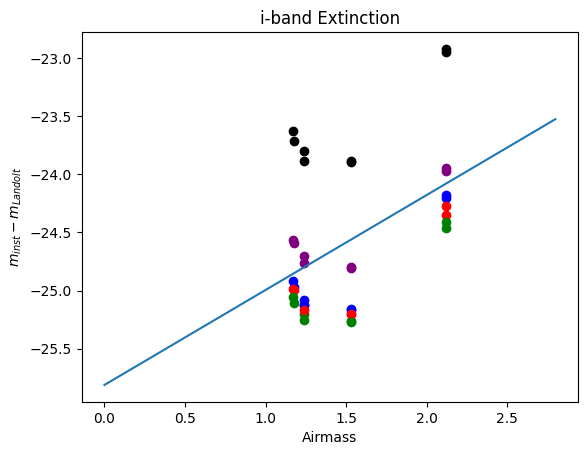

[np.float64(0.6659896703421928), np.float64(-0.23709144724877404), np.float64(0.4540849059918509), np.float64(0.7276866114451191), np.float64(0.816648624152535)]


In [1379]:
airmass_u = [1.18, 1.18, 1.23, 1.24, 1.49, 1.49, 2.04, 2.04]
airmass_b = [1.18, 1.18, 1.24, 1.24, 1.51, 1.51, 2.06, 2.08]
airmass_v = [1.18, 1.18, 1.24, 1.24, 1.52, 1.52, 2.10, 2.10]
airmass_r = [1.18, 1.18, 1.24, 1.24, 1.53, 1.53, 2.11, 2.11]
airmass_i = [1.18, 1.17, 1.24, 1.24, 1.53, 1.53, 2.12, 2.12]

airmasses = [airmass_u, airmass_b, airmass_v, airmass_r, airmass_i]
del_m = [del_m_u, del_m_b, del_m_v, del_m_r, del_m_i]
bands = ['u', 'b', 'v', 'r', 'i']
color = ['black', 'blue', 'red', 'green', 'purple']

extinctions = []
for band in range(len(bands)):
    filter = bands[band]
    x_filter = []
    y_filter = []
    for i in range(8):
        for star in range(5):
            del_m_val = del_m[band][i][star]
            airmass_val = airmasses[band][i]

            x_filter.append(airmass_val)
            y_filter.append(del_m_val)
            plt.scatter(airmass_val, del_m_val, color=color[star])
    
    k, b = np.polyfit(x_filter, y_filter, 1)
    extinctions.append(k)
    x_linfit = np.arange(0, 3, .2)
    plt.plot(x_linfit, k*x_linfit + b)
    plt.xlabel('Airmass')
    plt.ylabel(r'$m_{inst} - m_{Landolt}$')
    plt.title(filter+'-band Extinction')
    plt.show()

print(extinctions)


I am getting some really funky extinction values...the r and i band extinctions seem pretty high and I'm not sure why the b band is negative. Regardless, I moved on and used these values because I couldn't figure out where I went wrong since I already normalized each magnitude for exposure time.

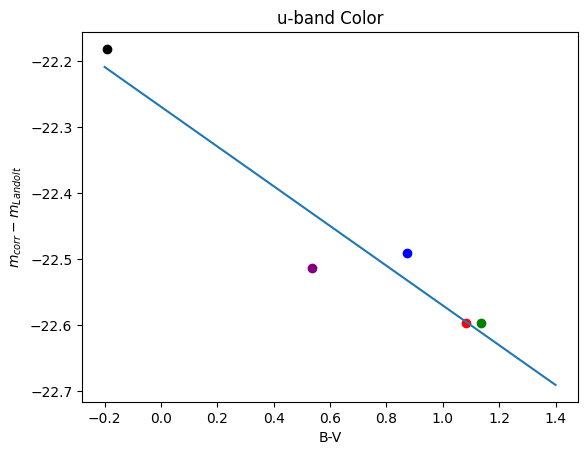

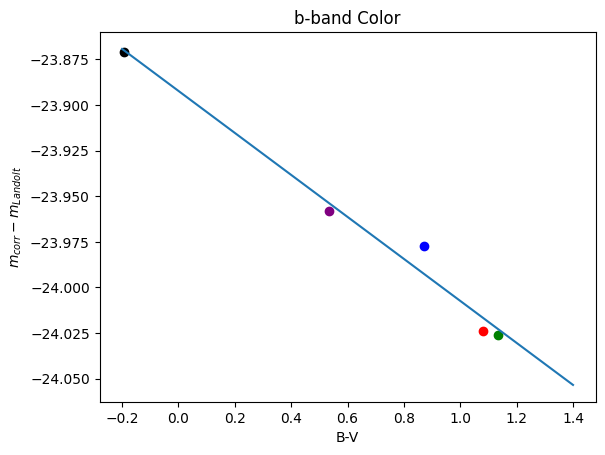

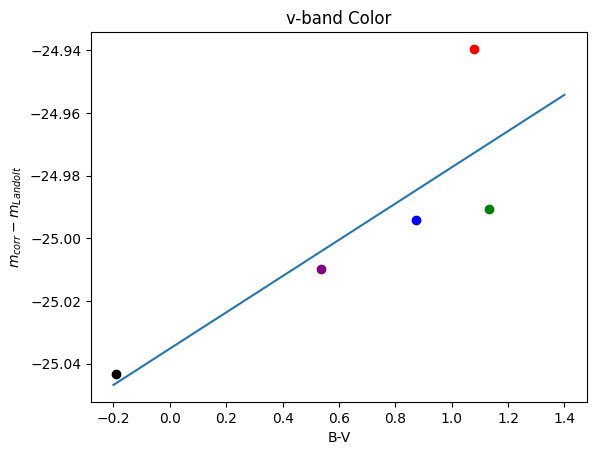

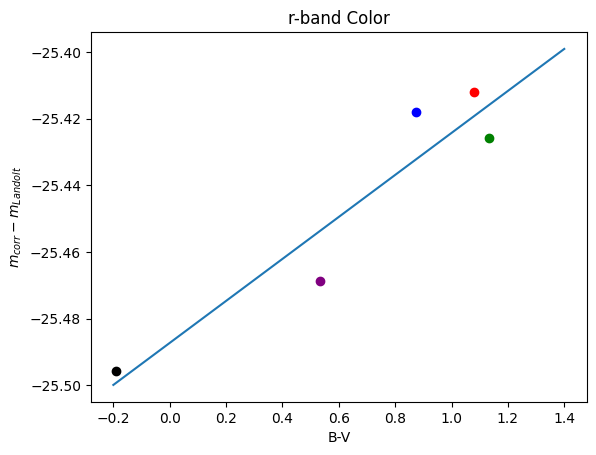

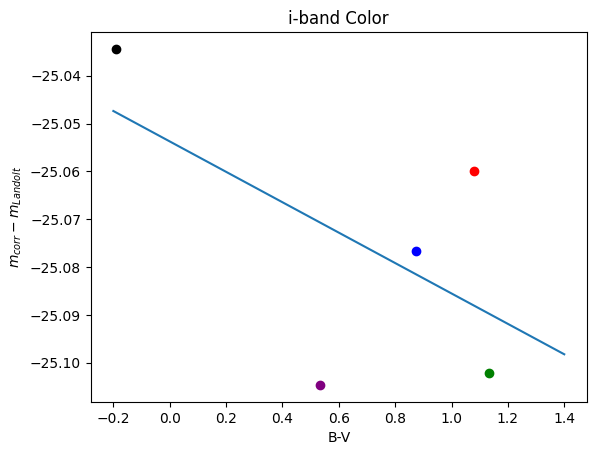

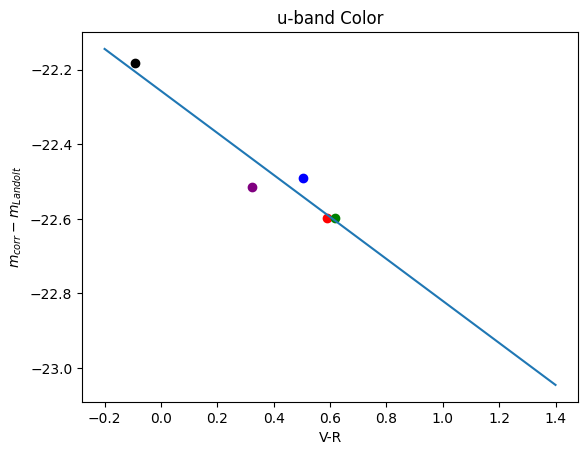

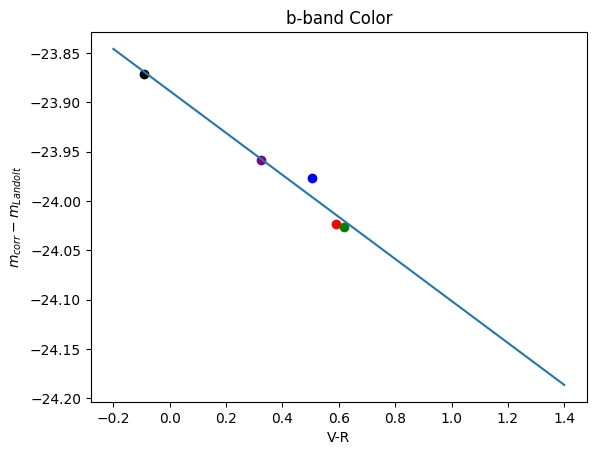

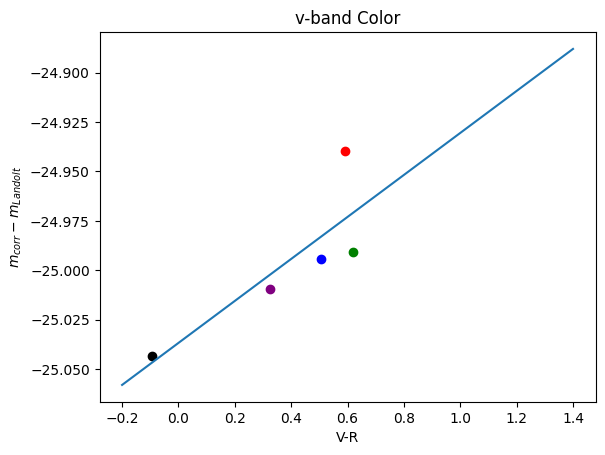

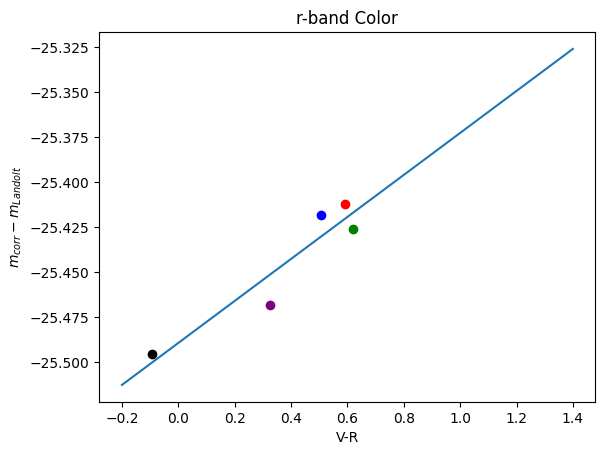

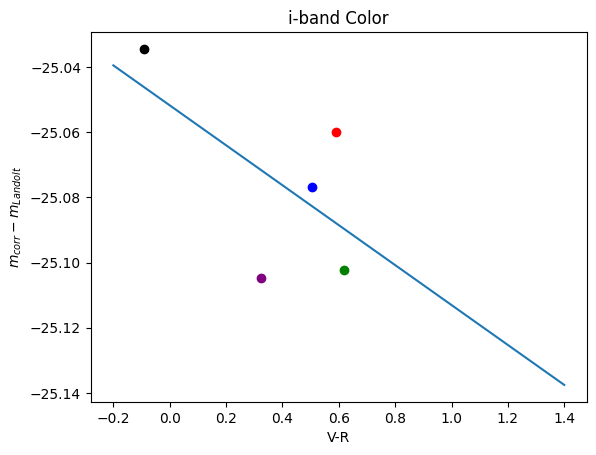

[np.float64(-0.3014544344719685), np.float64(-0.11507079163923291), np.float64(0.05784913702631647), np.float64(0.06298092049073764), np.float64(-0.03179606424472187)]
[np.float64(-0.5631967193936258), np.float64(-0.21281059022552512), np.float64(0.10628545149927492), np.float64(0.11689985157001825), np.float64(-0.061320675255275715)]
  band  extinction  zero_point  color_term_BV  color_term_VR
0    u    0.665990  -22.269047      -0.301454      -0.563197
1    b   -0.237091  -23.892310      -0.115071      -0.212811
2    v    0.454085  -25.035182       0.057849       0.106285
3    r    0.727687  -25.487253       0.062981       0.116900
4    i    0.816649  -25.053727      -0.031796      -0.061321


In [1380]:
mags = [mag_u, mag_b, mag_v, mag_r, mag_i]
m_corrs = []
c1s = []
z1s = []
c2s = []

b_v_landolt = [-.192, .873, 1.081, 1.134, .535]
u_b_landolt = [-.974, .320, 1.007, 1.138, 0.025]
v_r_landolt = [-.093, .505, .590, .618, .324]
v_i_landolt = [-.212, 1.015, 1.090, 1.138, .650]

true_us = []
true_bs = []
true_vs = []
true_rs = []
true_is = []
for star in range(5):
    true_magn = true_mag[star]
    true_b = true_magn + b_v_landolt[star]
    true_bs.append(true_b)
    true_u = true_b + u_b_landolt[star]
    true_us.append(true_u)
    true_v = true_magn
    true_vs.append(true_v)
    true_r = true_magn - v_r_landolt[star]
    true_rs.append(true_r)
    true_i = true_magn - v_i_landolt[star]
    true_is.append(true_i)
true_mags_corr = [true_us, true_bs, true_vs, true_rs, true_is]

for band in range(len(bands)):
    filter = bands[band]
    m_corr_band = []
    for i in range(8):
        m_corr_file = []
        for star in range(5):
            mag = mags[band][i][star]
            airmass = airmasses[band][i]
            k = extinctions[band]
            m_corr = mag - airmass*k

            m_corr_file.append(m_corr)
        m_corr_band.append(list(m_corr_file))
    m_corrs.append(list(m_corr_band))



for band in range(len(bands)):
    filter = bands[band]
    x1_filter = []
    y_filter = []
    
    for star in range(5):
        m_star_vals = []
        for i in range(8):
            m_corr = m_corrs[band][i][star]
            m_landolt = true_mags_corr[band][star]
            b_v_val = b_v_landolt[star]

            m_star_vals.append(m_corr)
    
        

        m_star_avg = np.mean(m_star_vals)
        del_m_corr = m_star_avg - m_landolt
        x1_filter.append(b_v_landolt[star])
        y_filter.append(del_m_corr)

        plt.scatter(b_v_landolt[star], del_m_corr, color=color[star])
    
    c1, z1 = np.polyfit(x1_filter, y_filter, 1)
    x1_linfit = np.arange(-.2, 1.5, .2)
    plt.plot(x1_linfit, c1*x1_linfit + z1)
    plt.xlabel('B-V')
    plt.ylabel(r'$m_{corr} - m_{Landolt}$')
    plt.title(filter+'-band Color')
    plt.show()
    c1s.append(c1)
    z1s.append(z1)


for band in range(len(bands)):
    filter = bands[band]
    x2_filter = []
    y_filter = []
    
    for star in range(5):
        m_star_vals = []
        for i in range(8):
            m_corr = m_corrs[band][i][star]
            m_landolt = true_mags_corr[band][star]
            v_r_val = v_r_landolt[star]

            m_star_vals.append(m_corr)
    
        

        m_star_avg = np.mean(m_star_vals)
        del_m_corr = m_star_avg - m_landolt
        x2_filter.append(v_r_landolt[star])
        y_filter.append(del_m_corr)

        plt.scatter(v_r_landolt[star], del_m_corr, color=color[star])
    
    c2, z2 = np.polyfit(x2_filter, y_filter, 1)
    x2_linfit = np.arange(-.2, 1.5, .2)
    plt.plot(x2_linfit, c2*x2_linfit + z2)
    plt.xlabel('V-R')
    plt.ylabel(r'$m_{corr} - m_{Landolt}$')
    plt.title(filter+'-band Color')
    plt.show()
    c2s.append(c2)


print(c1s)
print(c2s) 

import pandas as pd
color_table = pd.DataFrame({
    "band": bands,
    "extinction": extinctions,
    "zero_point": z1s,
    "color_term_BV": c1s,
    "color_term_VR": c2s
})
print(color_table)


For this section, I calculated each star's calibrated m value using the extinctions calculated from the previous question and averaged over all of them since they have the same B-V or V-R from Landolt (1992). I then used polyfit to fit a linear regression onto the 5 points to get color and zero-point values. 

Oh also! My table looks really nice and I'm quite happy with it!

In [1381]:
## CALIBRATED M VALUES

m_cals = []
for band in range(len(bands)):
    filter = bands[band]
    m_cal_band = []
    
    for i in range(8):
        m_cal_file = []
        for star in range(5):
            mag = mags[band][i][star]
            airmass = airmasses[band][i]
            k = extinctions[band]
            color_slope = c1s[band]
            z = z1s[band]
            m_cal = mag - airmass*k + z + color_slope * b_v_landolt[star]

            m_cal_file.append(m_cal)
        m_cal_band.append(m_cal_file)
    m_cals.append(list(m_cal_band))

final_mags = []

for band in range(len(bands)):
    band_results = []
    for star in range(5):
        values = []
        for i in range(8):
            values.append(m_cals[band][i][star])
        band_results.append(np.mean(values))
    final_mags.append(band_results)
print(final_mags)



[[np.float64(-31.161531544280628), np.float64(-28.57350205044031), np.float64(-30.134372778585114), np.float64(-29.706882334099696), np.float64(-30.6937623003748)], [np.float64(-33.53630378234541), np.float64(-31.84087170729385), np.float64(-33.990486870290816), np.float64(-33.6860386735111), np.float64(-33.68601662217445)], [np.float64(-35.6925379956076), np.float64(-34.72287247526967), np.float64(-36.94318528679189), np.float64(-36.73128273385239), np.float64(-36.32297628395509)], [np.float64(-36.50500014701694), np.float64(-36.09927022978993), np.float64(-38.45224267400149), np.float64(-38.23070826202998), np.float64(-37.55512908070806)], [np.float64(-35.47300901765077), np.float64(-35.91712337578325), np.float64(-38.26895487959244), np.float64(-38.10098230062138), np.float64(-37.134386062499914)]]


Did this step because I thought I had to only to realize I could've stopped at the last step...sorry!!!

 id      xcentroid      ...        b_v               mag_cal      
---- ------------------ ... ------------------ -------------------
   3  1285.530286619842 ... 3.1274896095190385  -36.29890256563649
   2 1129.0254909965677 ...  3.265393563831111 -35.406616151375296
   5    262.90793905804 ... 3.5091434565742716  -34.92746634843253
  12  1066.410314893445 ... 3.4509796038000005  -35.31778143609235
  13 1840.9481566406791 ... 3.3052129143740245  -35.62285235878544
  14  1359.692656404008 ... 3.2533366036411593  -35.73891310003588
  18  169.0298340477025 ...  3.206290522908276  -38.25954507013258
  19 428.71384706195215 ...  3.557441701903599  -34.80897569121993
  20    848.98075068097 ...  3.174582145321125 -35.733489292558176
  22 170.92158654379963 ... 3.0394292361124258  -36.71524493409955
 ...                ... ...                ...                 ...
1219  1944.286630842248 ... 3.1513089079991374  -36.45961971636692
1222 2002.5494735888992 ...  3.275622049833082  -34.3234547439

Text(0.5, 1.0, 'NGC Color-Magnitude Diagram')

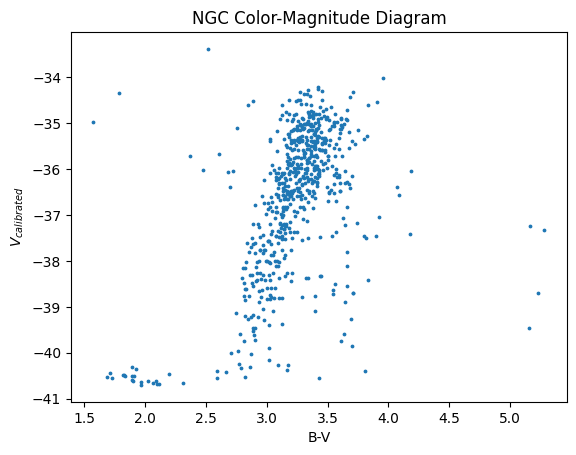

In [1398]:
# MAKE TABLES FOR V AND B BAND STARS

img_v = fits.getdata(reduced_dir + 'a159_otzf.fits')
mean_v, median_v, std_v = sigma_clipped_stats(img_v, sigma=3.0)
daofind = DAOStarFinder(fwhm=3.0, threshold=5*std_v)
sources_v = daofind(img_v - median_v)

img_b = fits.getdata(reduced_dir + 'a160_otzf.fits')
mean_b, median_b, std_b = sigma_clipped_stats(img_b, sigma=3.0)
daofind = DAOStarFinder(fwhm=3.0, threshold=5*std_b)
sources_b = daofind(img_b - median_b)

## CROSS MATCH V AND B STARS!

v_stars = np.array([sources_v['xcentroid'], sources_v['ycentroid']]).T
b_stars = np.array([sources_b['xcentroid'], sources_b['ycentroid']]).T

tree = cKDTree(v_stars)
distance, index = tree.query(b_stars, distance_upper_bound=3)

keep = distance < 3
v_stars_matched = sources_v[index[keep]]
b_stars_matched = sources_b[keep]


v_stars_matched['v_cal'] = v_stars_matched['mag'] - extinctions[2]*1.09 + +z1s[2]
b_stars_matched['b_cal'] = b_stars_matched['mag'] - extinctions[1]*1.09 + +z1s[1]
v_stars_matched['b_v'] = b_stars_matched['b_cal'] - v_stars_matched['v_cal']
v_stars_matched['mag_cal'] = v_stars_matched['v_cal'] + c1s[2] * v_stars_matched['b_v']
print(v_stars_matched)

plt.scatter(v_stars_matched['b_v'], v_stars_matched['mag_cal'], s=3)
plt.xlabel('B-V')
plt.ylabel(r'$V_{calibrated}$')
plt.title('NGC Color-Magnitude Diagram')


YAY! Color-magnitude diagram!! It was lots of blood, sweat, and tears to get here and I know some of it is still funky looking. 

Regardless, I enjoyed learning about observing the stars and how far science has come! Thank you for a wonderful semester :)